In [240]:
import numpy as np
import pandas as pd

In [241]:
class LogicticRegression():
    """
    Реализует алгоритм Логистической Регрессии для задач бинарной классификации.
    
    Модель строит линейную комбинацию входных признаков, преобразует полученный результат 
    в вероятность с помощью функции сигмоиды и производит классификацию по заданному порогу. 
    Обучение выполняется методом градиентного спуска с поддержкой критерия ранней остановки 
    и гибкой регуляризации ElasticNet (комбинация L1 и L2 штрафов).
    
    Аргументы инициализации:
    ----------------------------------
    max_iter : int, default=3000
        Максимальное количество эпох градиентного спуска для обучения модели.
    learning_rate : float, default=0.01
        Скорость обучения (шаг градиентного спуска), контролирующая величину обновления весов.
    stop_gr : float, default=1e-5
        Критерий ранней остановки. Обучение прерывается, если абсолютное изменение 
        функции потерь LogLoss между соседними эпохами становится меньше этого значения.
    l1, l2 : float, default=0.0
        Коэффициенты L1-регуляризации (Lasso) и L2-регуляризации (Ridge). Отвечают за отбор признаков путем зануления 
        неважных весов. При l1=0.0 и l2>0.0 модель активирует Ridge (L2), при l1>0.0 и l2=0.0 активируется Lasso (L1). 
        При одновременном l1>0.0 и l2>0.0 модель работает в режиме ElasticNet.
    
    Основные методы:
    ----------------
    sigmoid(x)
        Функция активации, преобразующая любое вещественное число в значение вероятности из диапазона от 0 до 1.
    LogLoss(pred, y)
        Вычисляет функцию потерь с учетом добавленных штрафов L1 и L2 регуляризаций.
    fit(X, y)
        Запускает цикл градиентного спуска для настройки весов и сдвига на обучающей выборке.
    predict_proba(X)
        Рассчитывает чистые вероятности принадлежности к положительному классу (1) 
        для объектов из переданной матрицы признаков X.
    predict(X, threshold=0.5)
        Предсказывает финальные метки классов (0 или 1) на основе рассчитанных вероятностей 
        и заданного порога отсечения (threshold).
    plot_loss
        Свойство класса которое визуализирует график падения функции потерь LogLoss по ходу эпох обучения.
    
    Внутренние атрибуты:
    --------------------
    self.weight : numpy.ndarray
        Вектор подобранных весов модели. Длина вектора равна количеству признаков в матрице X.
    self.intersept : float
        Свободный коэффициент модели (сдвиг/bias).
    self.loss_history : list
        Список значений функции потерь LogLoss на каждой эпохе для мониторинга обучения.
    self.epoch : int
        Фактическое количество эпох, которое потребовалось модели до завершения обучения.
    """
    def __init__(self, max_iter = 3000, learning_rate = 0.01, stop_gr = 1e-5, l1=0.0, l2 = 0.0):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.stop_gr = stop_gr
        self.l1 = l1
        self.l2 = l2


    def sigmoid(self, x):
        return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

    def LogLoss(self, pred, y):
        loss = -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))
        l1_loss = self.l1 * np.sum(np.abs(self.weight))
        l2_loss = (self.l2 * np.sum(self.weight ** 2)) / 2
        return loss + l2_loss + l1_loss

    def fit(self, X, y):
        self.weight = np.zeros(X.shape[1])
        self.intersept = 0
        self.loss_history = []
        
        prev_loss = float('inf')

        for epoch in range(self.max_iter):
            z = (X @ self.weight) +  self.intersept
            pred = self.sigmoid(z)
            
            eps = 1e-15
            clip_pred = np.clip(pred, eps, 1 - eps)
            loss = self.LogLoss(clip_pred, y)
            self.loss_history.append(loss)

            if abs(prev_loss - loss) < self.stop_gr:
                break
            prev_loss = loss

            dif = pred - y
            
            gr_intersept = np.mean(dif)
            gr_weight = ((X.T @ dif)/ len(X)) + (self.l2 * self.weight) + (self.l1 * np.sign(self.weight))

            self.intersept -= self.learning_rate * gr_intersept
            self.weight -= self.learning_rate * gr_weight
        self.epoch = epoch
        return self

    def predict_proba(self, X):
        z = (X @ self.weight) + self.intersept
        return self.sigmoid(z)

    def predict(self,X, threshold = 0.5):
        x = self.predict_proba(X)
        return np.where(x >= threshold,1,0)

    @property
    def plot_loss(self):
        return pd.DataFrame(self.loss_history).plot()
    

        

In [268]:
class MCLogisticRegression:
    """
    Реализует многоклассовую логистическую регрессию на основе стратегии "Один против всех" (One-vs-Rest / OvR).
    
    Класс является внешней оберткой над базовым алгоритмом бинарной логистической регрессии. 
    Для каждого уникального класса в целевой переменной y создается и обучается отдельная 
    независимая модель LogicticRegression, которая учится отличать свой класс от всех остальных. 
    Итоговый класс определяется по принципу максимизации предсказанной вероятности.
    
    Аргументы инициализации:
    ----------------------------------
    max_iter : int, default=3000
        Максимальное количество эпох обучения градиентного спуска для каждой бинарной модели.
    learning_rate : float, default=0.01
        Скорость обучения (шаг градиентного спуска) для внутренних моделей.
    stop_gr : float, default=1e-5
        Критерий ранней остановки для досрочного завершения обучения бинарных моделей.
    l1 : float, default=0.0
        Коэффициент L1-регуляризации (Lasso) для отбора признаков во внутренних моделях.
    l2 : float, default=0.0
        Коэффициент L2-регуляризации (Ridge) для предотвращения переобучения во внутренних моделях.
    
    Основные методы:
    ----------------
    fit(X, y)
        Запускает процесс многоклассового обучения: определяет уникальные классы в y, 
        проводит бинаризацию целевой переменной для каждого из них и обучает 
        соответствующие изолированные экземпляры класса LogicticRegression.
    predict_proba(X)
        Рассчитывает матрицу вероятностей, где каждая строка соответствует объекту из X, 
        а каждый столбец — вероятности отнесения объекта к конкретному классу одной из моделей.
    predict(X)
        Предсказывает итоговые текстовые или числовые метки классов для объектов из матрицы X. 
        Выбирает тот класс, чья бинарная модель выдала максимальную вероятность (через np.argmax).
    predict_proba_df(X)
        Возвращает результаты метода predict_proba(X) в виде красиво оформленной таблицы 
        pandas.DataFrame, где столбцы подписаны реальными названиями классов, а индексы строк 
        сохраняют оригинальную разметку переданного датасета X.
    
    Внутренние атрибуты:
    --------------------
    self.models : dict
        Словарь, в котором ключами являются уникальные имена исходных классов (cls), 
        а значениями — обученные для них экземпляры класса LogicticRegression.
    """

    def __init__(self, max_iter = 3000, learning_rate = 0.01, stop_gr = 1e-5, l1=0.0, l2 = 0.0):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.stop_gr = stop_gr
        self.l1 = l1
        self.l2 = l2
        self.models = dict()

    def fit(self, X, y):
        uniq_y = np.unique(y)

        for cls in uniq_y:
            y_binary = np.where(y==cls,1,0)
            model = LogicticRegression(max_iter = self.max_iter, learning_rate=self.learning_rate, 
                                       stop_gr = self.stop_gr, l1=self.l1, l2=self.l2).fit(X, y_binary)
            self.models[cls] = model
        return self

    def predict_proba(self, X):
        proba_list = [model.predict_proba(X) for cls, model in self.models.items()]
        proba_matrix = np.column_stack(proba_list)
        return proba_matrix

    def predict(self,X):
        matrix = self.predict_proba(X)
        max_pred =  np.argmax(matrix, axis=1)
        classes = np.array(list(self.models.keys()))
        return classes[max_pred]

    def predict_proba_df(self,X):
        matrix = self.predict_proba(X)
        class_names = list(self.models.keys())
        df = pd.DataFrame(matrix, columns=class_names)
        if hasattr(X, 'index'):
            df.index = X.index
        return df

In [304]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

my_model = LogicticRegression(max_iter=1500, learning_rate=0.1, l2 = 0.1).fit(X_train_scaled, y_train)
my_preds = my_model.predict(X_test_scaled)

my_accuracy = np.mean(my_preds == y_test)

## Визуализация ошибки

<Axes: >

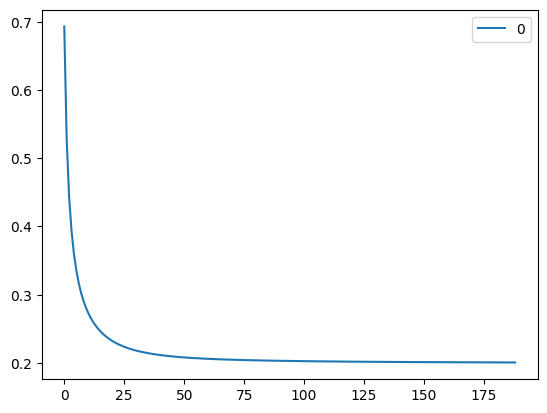

In [305]:
my_model.plot_loss

In [306]:
print(f'Модель обучилась за {my_model.epoch} эпох')

Модель обучилась за 188 эпох


In [307]:
from sklearn.linear_model import LogisticRegression


sk_model = LogisticRegression().fit(X_train_scaled, y_train)
sk_preds = sk_model.predict(X_test_scaled)

sk_accuracy = np.mean(sk_preds == y_test)

In [308]:
print(f"Точность кастомной модели на тесте: {my_accuracy * 100:.2f}%")
print(f"Точность sklearn модели на тесте: {sk_accuracy * 100:.2f}%")

Точность кастомной модели на тесте: 98.25%
Точность sklearn модели на тесте: 97.37%


**Веса при l1 регуляризации**

<Axes: >

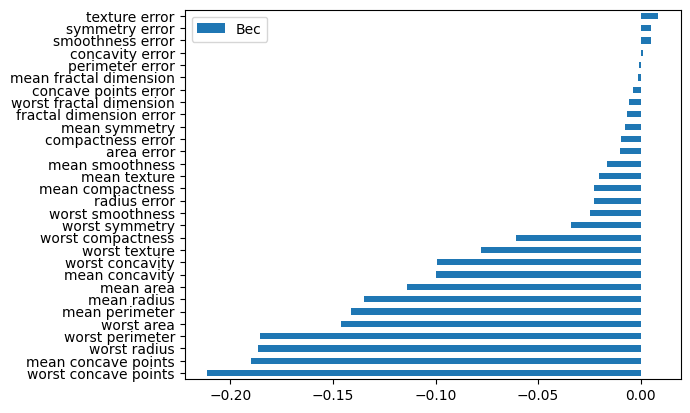

In [303]:
pd.DataFrame(my_model.weight, index = data.feature_names, columns=['Вес']).sort_values(by = 'Вес').plot.barh()

**Веса при l2 регуляризации**

<Axes: >

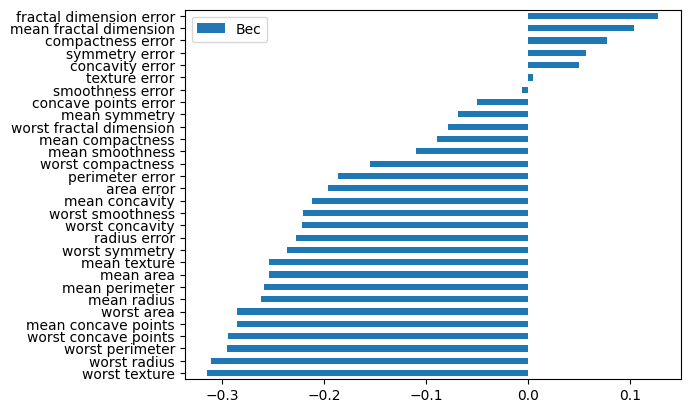

In [309]:
pd.DataFrame(my_model.weight, index = data.feature_names, columns=['Вес']).sort_values(by = 'Вес').plot.barh()

## Проверка на мультиклассовую классификацию

In [274]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series([iris.target_names[i] for i in iris.target])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)



In [275]:
mc_model = MCLogisticRegression(learning_rate=0.1, l2=0.01)
mc_model.fit(X_train_scaled, y_train)

test_preds = mc_model.predict(X_test_scaled)
accuracy = np.mean(test_preds == y_test)
print(f"Общая точность многоклассовой модели на тесте: {accuracy * 100:.2f}%\n")

Общая точность многоклассовой модели на тесте: 96.67%



In [276]:
proba_df = mc_model.predict_proba_df(X_test_scaled)
proba_df['Реальный класс'] = y_test.values
proba_df['Предсказание'] = test_preds
proba_df.head(12)

,setosa,versicolor,virginica,Реальный класс,Предсказание
73,0.0303,0.5151,0.1785,versicolor,versicolor
18,0.9780,0.0584,0.0003,setosa,setosa
118,0.0001,0.6857,0.9906,virginica,virginica
78,0.0306,0.3984,0.2934,versicolor,versicolor
76,0.0099,0.5352,0.3468,versicolor,versicolor
31,0.9512,0.1370,0.0004,setosa,setosa
64,0.1237,0.3667,0.0758,versicolor,versicolor
141,0.0033,0.2601,0.9090,virginica,virginica
68,0.0037,0.8236,0.4237,versicolor,versicolor
82,0.0582,0.5349,0.0895,versicolor,versicolor


In [312]:
for name_fich, model in mc_model.models.items():
    print(f'Модель для {name_fich} прошла {model.epoch} эпох')

Модель для setosa прошла 551 эпох
Модель для versicolor прошла 351 эпох
Модель для virginica прошла 1113 эпох
